# Parte 3: Comparación con scikit-learn

**Trabajo Práctico — Matemática III: Redes Neuronales**  
**Dataset:** Water Potability  
**Integrantes:** Micaela Ortiz y Camila Maldonado

---

En esta parte implementamos la misma red neuronal de la Parte 2 usando `scikit-learn`, comparamos los resultados y exploramos arquitecturas alternativas.

In [12]:
# Importamos numpy para operaciones numericas.
import numpy as np

# Importamos pandas para leer y preparar datos.
import pandas as pd

# Importamos matplotlib para graficar resultados.
import matplotlib.pyplot as plt

# train_test_split separa datos en entrenamiento y prueba.
from sklearn.model_selection import train_test_split

# MLPClassifier es la red neuronal de scikit-learn para clasificacion.
from sklearn.neural_network import MLPClassifier

# accuracy_score calcula la proporcion de aciertos.
from sklearn.metrics import accuracy_score


In [13]:
# Leemos el dataset.
df = pd.read_csv("../data/water_potability.csv")

# Imputamos faltantes con la mediana, igual que en Partes 1 y 2.
df["ph"] = df["ph"].fillna(df["ph"].median())
df["Sulfate"] = df["Sulfate"].fillna(df["Sulfate"].median())
df["Trihalomethanes"] = df["Trihalomethanes"].fillna(df["Trihalomethanes"].median())

# X son las variables de entrada.
X = df.drop(columns=["Potability"]).values.astype(float)

# y es la variable objetivo.
y = df["Potability"].values

# Normalizamos X con Z-score.
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Separamos train/test con la misma proporcion usada en Parte 2.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=1/3,
    random_state=42
)

# Mostramos dimensiones.
X_train.shape, X_test.shape


((2184, 9), (1092, 9))

In [14]:
# Creamos un modelo MLPClassifier equivalente a la red de Parte 2.
modelo = MLPClassifier(
    # Una capa oculta con 8 neuronas.
    hidden_layer_sizes=(8,),

    # Funcion de activacion ReLU para la capa oculta.
    activation="relu",

    # Usamos descenso por gradiente estocastico.
    solver="sgd",

    # Tasa de aprendizaje.
    learning_rate_init=0.01,

    # Cantidad maxima de iteraciones internas de sklearn.
    max_iter=1000,

    # Semilla para reproducibilidad.
    random_state=10
)

# Entrenamos el modelo con los datos de entrenamiento.
modelo.fit(X_train, y_train)

# Predicciones sobre entrenamiento.
pred_train = modelo.predict(X_train)

# Predicciones sobre test.
pred_test = modelo.predict(X_test)

# Accuracy en entrenamiento.
acc_train_sklearn = accuracy_score(y_train, pred_train)

# Accuracy en test.
acc_test_sklearn = accuracy_score(y_test, pred_test)

print("Accuracy train sklearn:", acc_train_sklearn)
print("Accuracy test sklearn:", acc_test_sklearn)


Accuracy train sklearn: 0.6872710622710623
Accuracy test sklearn: 0.663003663003663


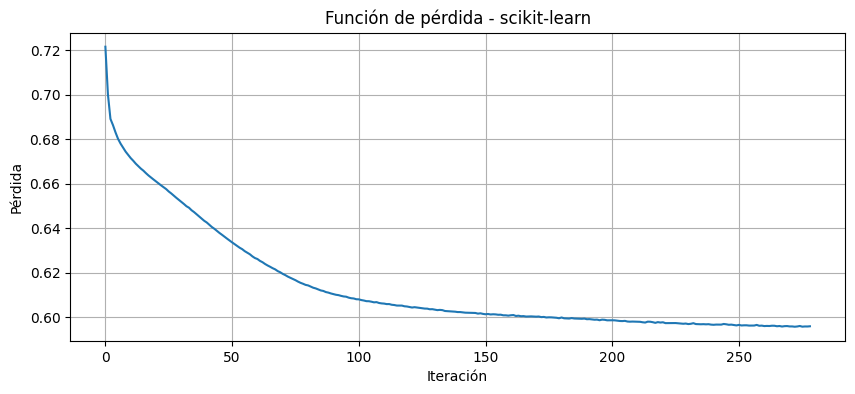

In [15]:
# Graficamos la funcion de perdida que sklearn guarda durante el entrenamiento.
plt.figure(figsize=(10, 4))

# loss_curve_ contiene el valor de perdida en cada iteracion de entrenamiento.
plt.plot(modelo.loss_curve_)

plt.title("Función de pérdida - scikit-learn")
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.grid()
plt.show()


In [16]:
# Guardamos manualmente los resultados finales obtenidos en Parte 2 con NumPy.
acc_train_numpy = 0.6726
acc_test_numpy = 0.6758

# Armamos una tabla para comparar NumPy vs scikit-learn.
comparacion = pd.DataFrame({
    "Modelo": ["NumPy", "scikit-learn"],
    "Accuracy train": [acc_train_numpy, acc_train_sklearn],
    "Accuracy test": [acc_test_numpy, acc_test_sklearn]
})

# Mostramos la tabla.
comparacion


,Modelo,Accuracy train,Accuracy test
0,NumPy,0.672600,0.675800
1,scikit-learn,0.687271,0.663004


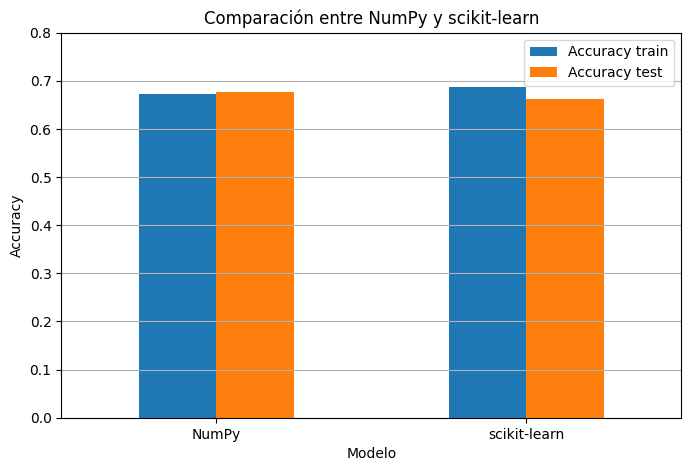

In [17]:
# Graficamos la comparacion de accuracy.
comparacion.plot(
    x="Modelo",
    y=["Accuracy train", "Accuracy test"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Comparación entre NumPy y scikit-learn")
plt.ylabel("Accuracy")
plt.ylim(0, 0.8)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()


In [18]:
# Definimos distintas arquitecturas para probar.
# Cada tupla tiene un nombre y la configuracion de capas ocultas.
arquitecturas = [
    ("8 neuronas", (8,)),
    ("16 neuronas", (16,)),
    ("32 neuronas", (32,)),
    ("2 capas: 16 y 8", (16, 8))
]

# Lista donde vamos a guardar resultados.
resultados = []

# Entrenamos un modelo para cada arquitectura.
for nombre, capas in arquitecturas:
    modelo = MLPClassifier(
        # Cantidad de neuronas/capas ocultas.
        hidden_layer_sizes=capas,

        # Misma activacion que antes.
        activation="relu",

        # Mismo optimizador.
        solver="sgd",

        # Misma tasa de aprendizaje.
        learning_rate_init=0.01,

        # Mismo maximo de iteraciones.
        max_iter=1000,

        # Misma seed para que la comparacion sea reproducible.
        random_state=10
    )

    # Entrenamos el modelo.
    modelo.fit(X_train, y_train)

    # Predicciones en train y test.
    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    # Guardamos accuracy de train y test para esta arquitectura.
    resultados.append({
        "Arquitectura": nombre,
        "Accuracy train": accuracy_score(y_train, pred_train),
        "Accuracy test": accuracy_score(y_test, pred_test)
    })

# Convertimos la lista de resultados en DataFrame.
df_resultados = pd.DataFrame(resultados)

# Mostramos la tabla final.
df_resultados


,Arquitectura,Accuracy train,Accuracy test
0,8 neuronas,0.687271,0.663004
1,16 neuronas,0.706502,0.674908
2,32 neuronas,0.748168,0.640110
3,2 capas: 16 y 8,0.751832,0.657509


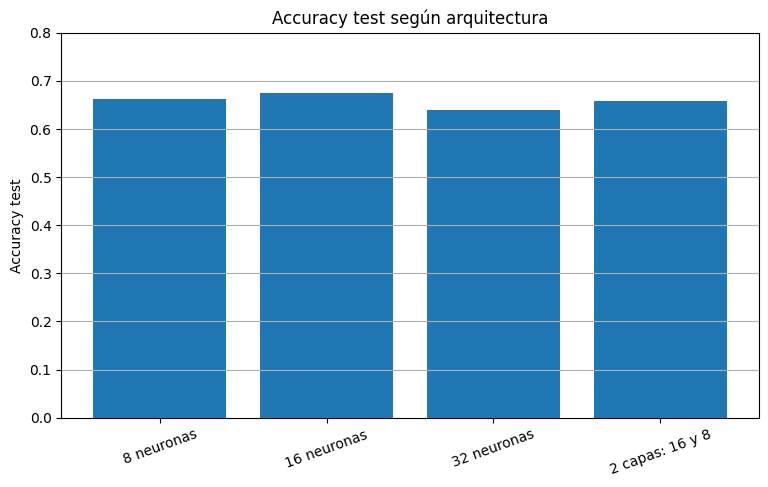

In [19]:
# Graficamos la accuracy de test de cada arquitectura.
plt.figure(figsize=(9, 5))

plt.bar(df_resultados["Arquitectura"], df_resultados["Accuracy test"])

plt.title("Accuracy test según arquitectura")
plt.ylabel("Accuracy test")
plt.ylim(0, 0.8)
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()
